In [1]:
import ast
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, UtilityAlignedTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo
from utils import *
from xgboost import XGBClassifier

/home/alexis/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_SEED = 42

def test_equivalent(explainer, X_test, n_samples):
    res = []
    for i in range(n_samples):
        best_attribution = explainer.extract_utility_attribution(X_test.iloc[[i]])[0]["features"]
        best_explanation = list(ast.literal_eval(explainer.explain_instance(X_test.iloc[i])[0]["features"]))
        res.append({"Best attribution": best_attribution, "Best explication": best_explanation, "Belong": best_attribution in best_explanation})
    return pd.DataFrame(res)

## Loan Approval dataset

In [3]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")
loan_df

X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=RANDOM_SEED)

X_train_loan = X_train_loan.reset_index(drop=True)
X_test_loan = X_test_loan.reset_index(drop=True)
y_train_loan = y_train_loan.reset_index(drop=True)
y_test_loan = y_test_loan.reset_index(drop=True)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
loan_categorical_indices = [loan_features.index(col) for col in categorical_cols]
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
loan_model.fit(X_train_processed_loan, y_train_loan)

loan_class_names = [str(c) for c in sorted(loan_df['loan_status'].unique())]

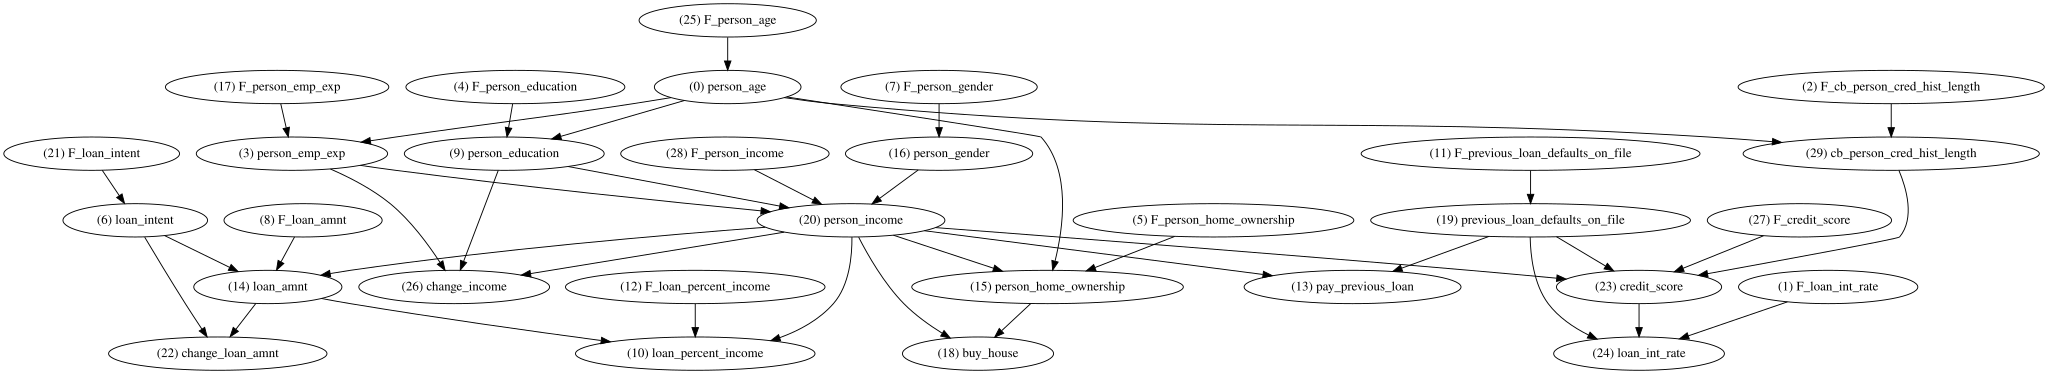

In [4]:
loan_actions = [
    "buy_house",
    "change_loan_amnt", 
    "change_income", 
    "pay_previous_loan"
]

loan_utility_matrix = np.array([[-12, 0], [-7, 0], [-12, 0], [-6, 0]])

loan_causal = CausalModel(features=loan_features, actions=loan_actions)

loan_causal.add_causal_edge("person_age", "person_emp_exp")
loan_causal.add_causal_edge("person_age", "cb_person_cred_hist_length")
loan_causal.add_causal_edge("person_age", "person_education")

loan_causal.add_causal_edge("person_education", "person_income")
loan_causal.add_causal_edge("person_emp_exp", "person_income")

loan_causal.add_causal_edge("person_income", "person_home_ownership")
loan_causal.add_causal_edge("person_age", "person_home_ownership")

loan_causal.add_causal_edge("cb_person_cred_hist_length", "credit_score")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "credit_score")
loan_causal.add_causal_edge("person_income", "credit_score")

loan_causal.add_causal_edge("loan_intent", "loan_amnt")
loan_causal.add_causal_edge("person_income", "loan_amnt")

loan_causal.add_causal_edge("loan_amnt", "loan_percent_income")
loan_causal.add_causal_edge("person_income", "loan_percent_income")

loan_causal.add_causal_edge("credit_score", "loan_int_rate")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "loan_int_rate")
#loan_causal.add_causal_edge("loan_percent_income", "loan_int_rate")
#loan_causal.add_causal_edge("person_home_ownership", "loan_int_rate")

loan_causal.add_causal_edge("person_gender", "person_income")

loan_causal.add_causal_edge("person_income", "buy_house")
loan_causal.add_causal_edge("person_home_ownership", "buy_house")

loan_causal.add_causal_edge("loan_amnt", "change_loan_amnt")
loan_causal.add_causal_edge("loan_intent", "change_loan_amnt")

loan_causal.add_causal_edge("person_income", "change_income")
loan_causal.add_causal_edge("person_education", "change_income")
loan_causal.add_causal_edge("person_emp_exp", "change_income")

loan_causal.add_causal_edge("previous_loan_defaults_on_file", "pay_previous_loan")
loan_causal.add_causal_edge("person_income", "pay_previous_loan")

dag = loan_causal.getDAG()
loan_dot = dag.toDot()
loan_graph = graphviz.Source(loan_dot)
display(loan_graph)

/home/alexis/UtilityAlignedExplainer/decision_maker.py:1122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_jaccard, x="Metric", y="Score", ax=axes[0, 0], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_utility, x="Metric", y="Score", ax=axes[0, 1], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_info, x="Metric", 

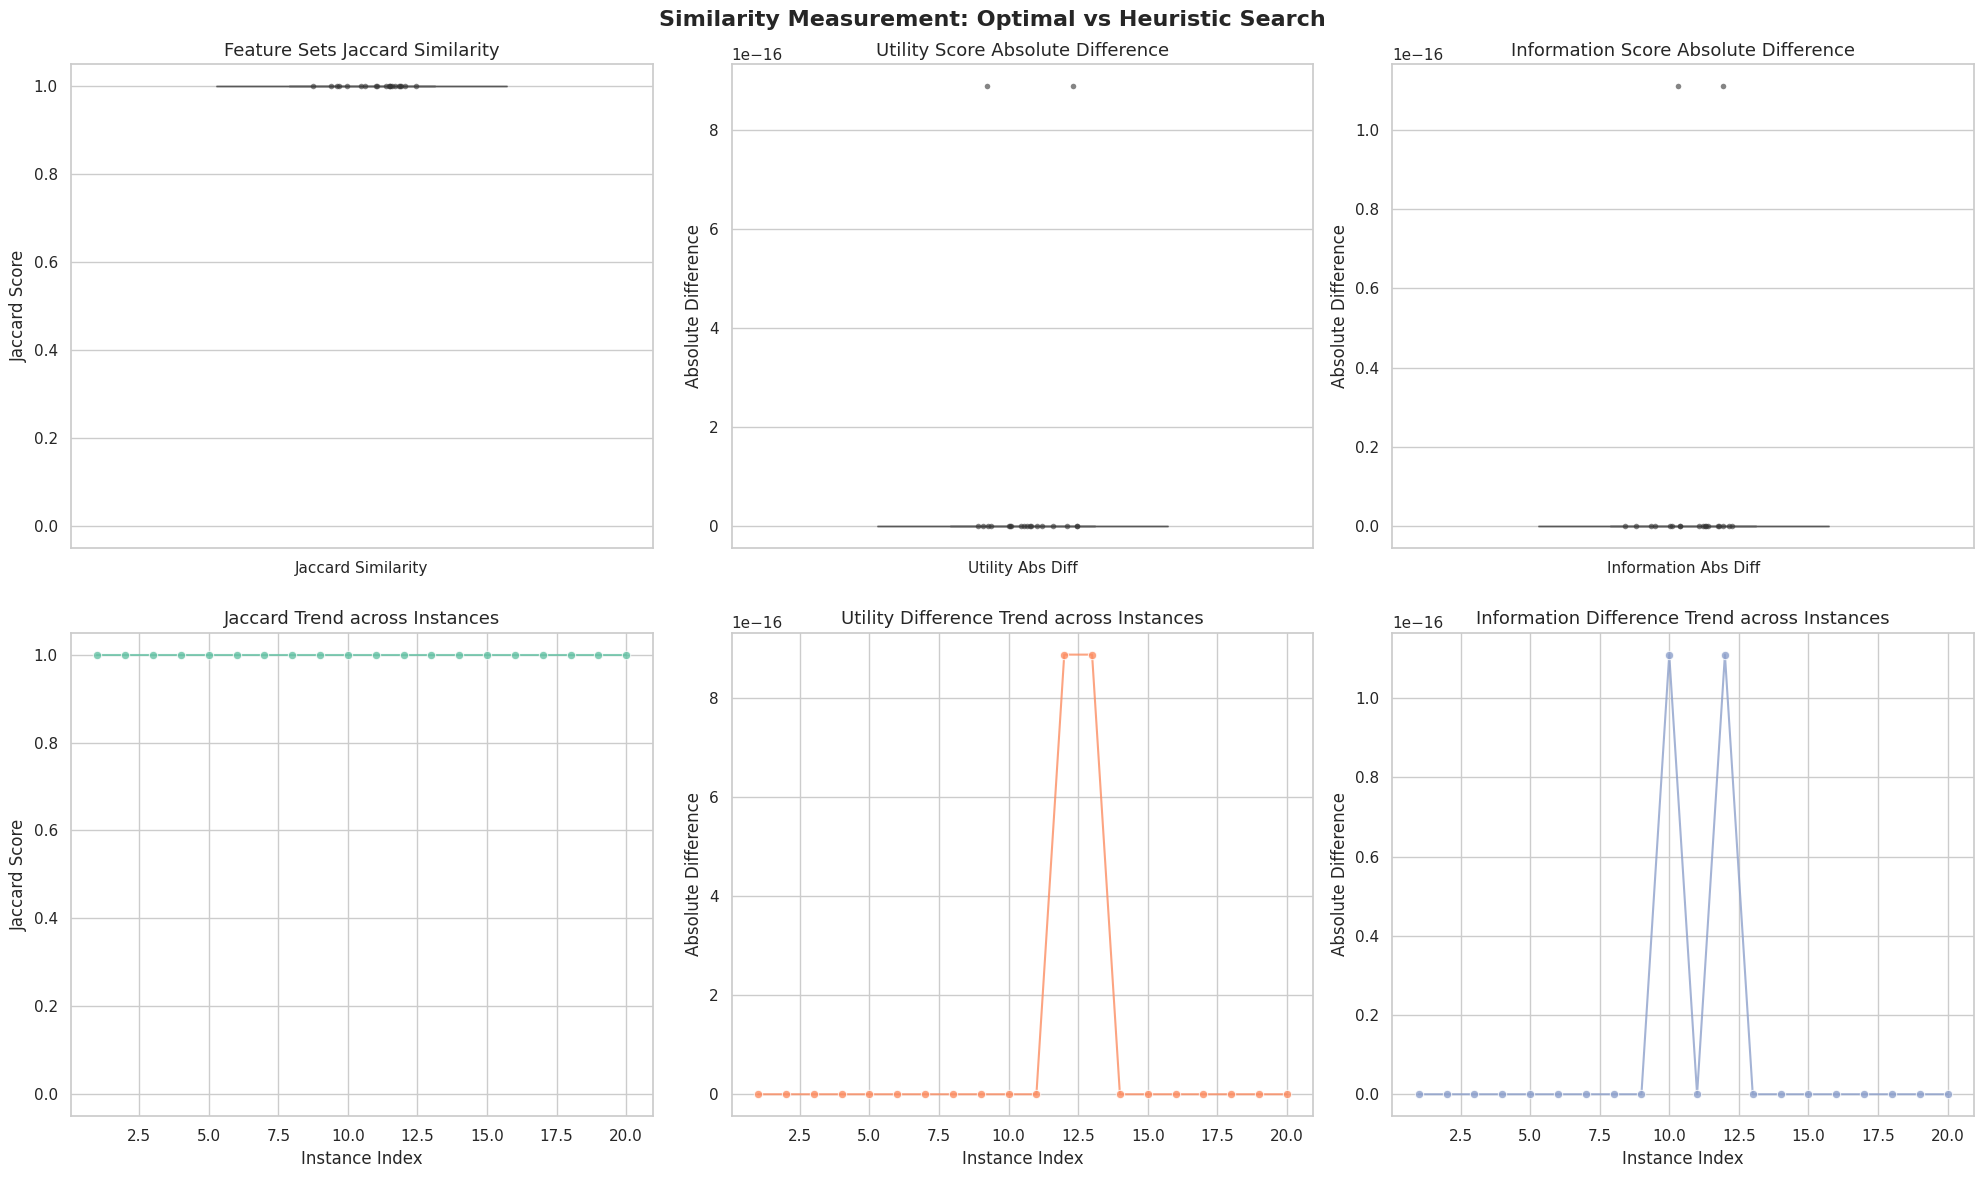

{'jaccard_similarity': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'utility_difference': [np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(8.881784197001252e-16),
  np.float64(8.881784197001252e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0)],
 'information_difference': [np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(1.1102230246251565e-16),
  np.float64(0.0),
  np.float64(1.1102230246251565e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float6

In [5]:
loan_explainer_user = UtilityAlignedExplainerUser(
    model = loan_model,
    features=loan_features,
    actions=loan_actions,
    X_train=X_train_processed_loan,
    X_test=X_test_processed_loan,
    causal_model=loan_causal,
    utility_matrix=loan_utility_matrix,
    n_samples=20
)

loan_explainer_user.similarity_measurement(display=True)

## Adult Income

In [6]:
X_adult, y_adult = shap.datasets.adult()
X_adult.columns = X_adult.columns.str.replace(r'[\s\-]+', '_', regex=True)
X_adult = X_adult.astype(float)
y_adult = y_adult.astype(int)

In [7]:
adult_features = X_adult.columns.to_list()
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(X_adult, y_adult, test_size=0.2, random_state=RANDOM_SEED)

X_train_adult = X_train_adult.reset_index(drop=True)
X_test_adult = X_test_adult.reset_index(drop=True)

adult_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
adult_model.fit(X_train_adult, y_train_adult)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


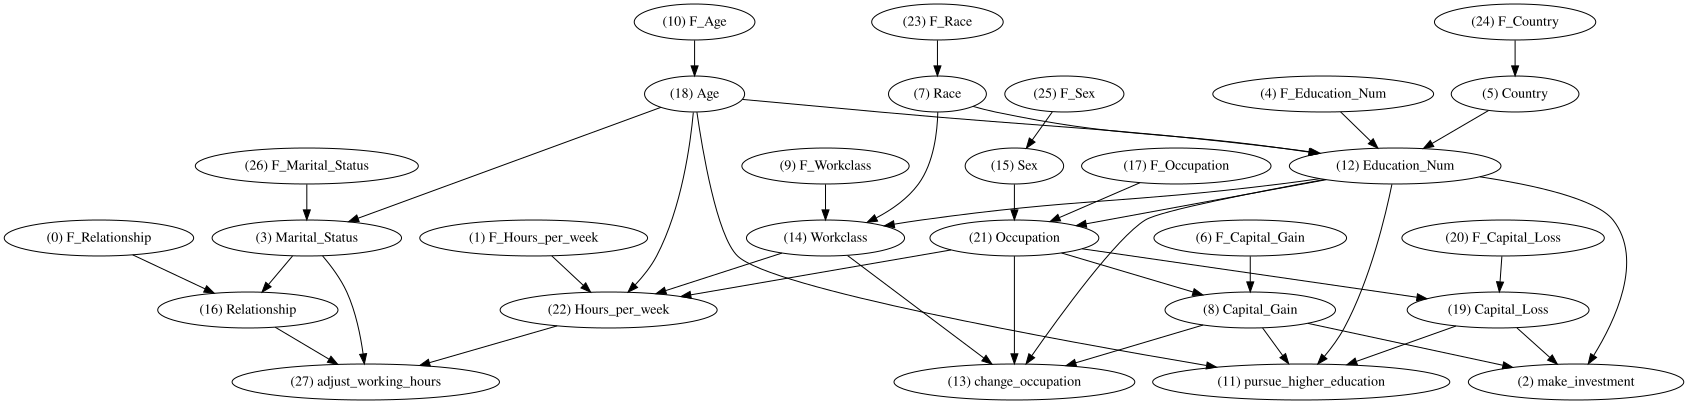

In [8]:
adult_actions = [
    'pursue_higher_education',
    'change_occupation',
    'adjust_working_hours',
    'make_investment'
]

adult_utility_matrix = np.array([
    [-5, 10],  # pursue_higher_education
    [-3,  7],  # change_occupation
    [-1,  4],  # adjust_working_hours
    [-4,  8]   # make_investment
])

adult_causal = CausalModel(features=adult_features, actions=adult_actions)

adult_causal.add_causal_edge('Age', 'Education_Num')
adult_causal.add_causal_edge('Age', 'Marital_Status')
adult_causal.add_causal_edge('Age', 'Hours_per_week')

adult_causal.add_causal_edge('Country', 'Education_Num')
adult_causal.add_causal_edge('Race', 'Education_Num')
adult_causal.add_causal_edge('Sex', 'Occupation')

adult_causal.add_causal_edge('Education_Num', 'Occupation')
adult_causal.add_causal_edge('Education_Num', 'Workclass')

adult_causal.add_causal_edge('Marital_Status', 'Relationship')

adult_causal.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal.add_causal_edge('Occupation', 'Capital_Loss')

adult_causal.add_causal_edge('Race', 'Workclass')

adult_causal.add_causal_edge('Workclass', 'Hours_per_week')

adult_causal.add_causal_edge('Age', 'pursue_higher_education')
adult_causal.add_causal_edge('Education_Num', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Gain', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Loss', 'pursue_higher_education')

adult_causal.add_causal_edge('Occupation', 'change_occupation')
adult_causal.add_causal_edge('Education_Num', 'change_occupation')
adult_causal.add_causal_edge('Workclass', 'change_occupation')
adult_causal.add_causal_edge('Capital_Gain', 'change_occupation')

adult_causal.add_causal_edge('Hours_per_week', 'adjust_working_hours')
adult_causal.add_causal_edge('Marital_Status', 'adjust_working_hours')
adult_causal.add_causal_edge('Relationship', 'adjust_working_hours')

adult_causal.add_causal_edge('Capital_Gain', 'make_investment')
adult_causal.add_causal_edge('Capital_Loss', 'make_investment')
adult_causal.add_causal_edge('Education_Num', 'make_investment')

dag = adult_causal.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

/home/alexis/UtilityAlignedExplainer/decision_maker.py:1122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_jaccard, x="Metric", y="Score", ax=axes[0, 0], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_utility, x="Metric", y="Score", ax=axes[0, 1], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_info, x="Metric", 

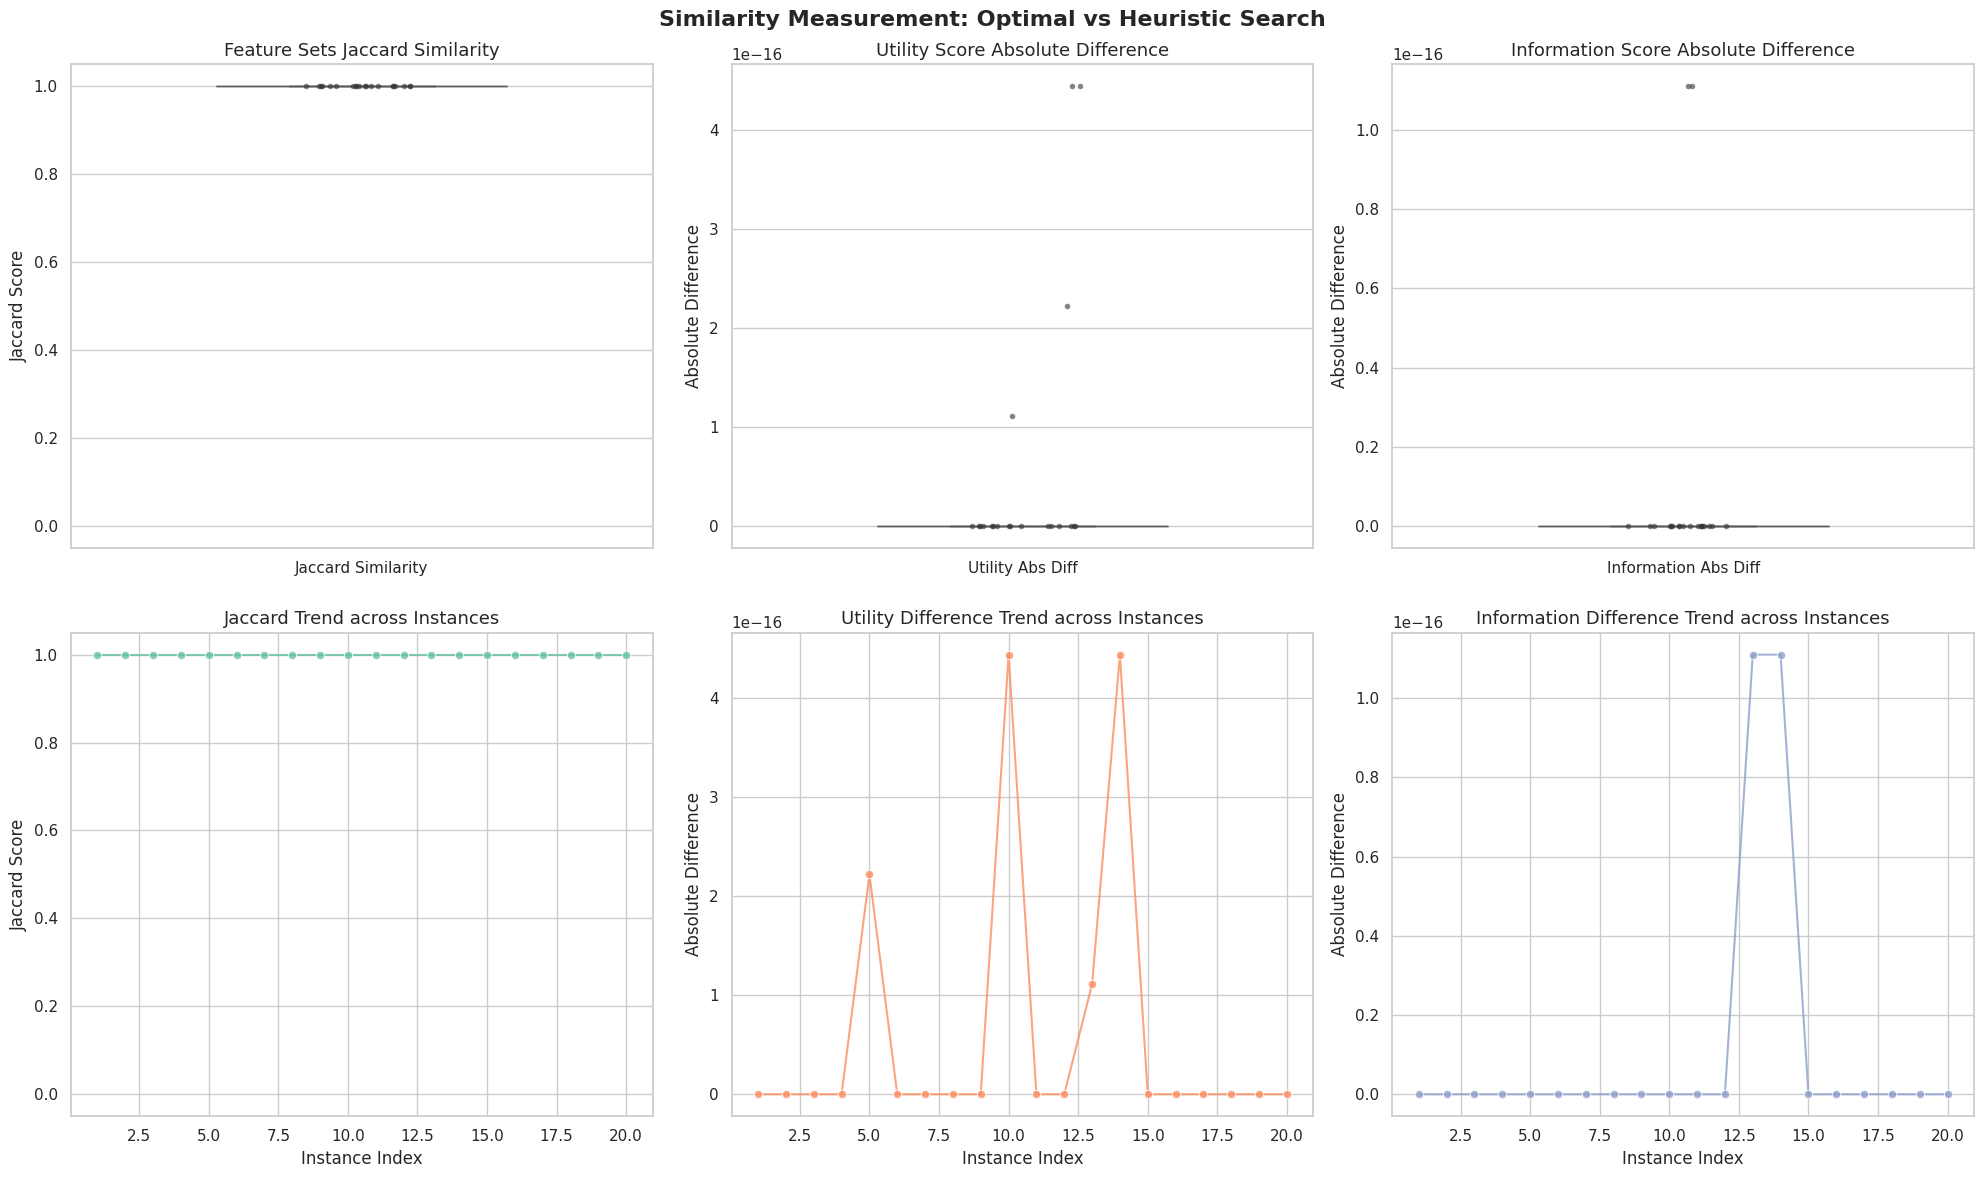

{'jaccard_similarity': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'utility_difference': [np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(2.220446049250313e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(1.1102230246251565e-16),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0)],
 'information_difference': [np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(1.1102230246251565e-16),
  np.float64(1.1102230246251565e-16),
  np.float64(0.0),
  np.float64

In [9]:
adult_explainer_user = UtilityAlignedExplainerUser(
    model = adult_model,
    features=adult_features,
    actions=adult_actions,
    X_train=X_train_adult,
    X_test=X_test_adult,
    causal_model=adult_causal,
    utility_matrix=adult_utility_matrix,
    n_samples=20
)

adult_explainer_user.similarity_measurement(display = True)

## UCI Heart Disease

In [10]:
heart_disease = fetch_ucirepo(id=45)
X_heart = heart_disease.data.features.dropna()
y_heart = heart_disease.data.targets.loc[X_heart.index]
X_heart = X_heart.astype(float)

In [11]:
heart_features = X_heart.columns.to_list()

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_heart, y_heart, test_size=0.2, random_state=RANDOM_SEED)

X_train_heart = X_train_heart.reset_index(drop=True)
X_test_heart = X_test_heart.reset_index(drop=True)
y_train_heart = y_train_heart.reset_index(drop=True)
y_test_heart = y_test_heart.reset_index(drop=True)

categorical_cols = X_heart.select_dtypes(include=['object']).columns.tolist()
heart_categorical_indices = [heart_features.index(col) for col in categorical_cols]

heart_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
heart_model.fit(X_train_heart, y_train_heart)

heart_class_names = [str(c) for c in sorted(np.unique(y_heart.values))]

/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [12]:
def add_pathophysiology_edges(causal_model):
    causal_model.add_causal_edge('age', 'trestbps')
    causal_model.add_causal_edge('age', 'chol')
    causal_model.add_causal_edge('age', 'thalach')

    causal_model.add_causal_edge('sex', 'chol')
    causal_model.add_causal_edge('sex', 'thal')
    
    causal_model.add_causal_edge('trestbps', 'cp')
    causal_model.add_causal_edge('chol', 'cp')
    causal_model.add_causal_edge('fbs', 'cp')
    causal_model.add_causal_edge('cp', 'exang')
    
    causal_model.add_causal_edge('chol', 'ca')
    causal_model.add_causal_edge('trestbps', 'restecg')
    causal_model.add_causal_edge('thalach', 'oldpeak')
    causal_model.add_causal_edge('oldpeak', 'slope')

### Patient-based

In [13]:
patient_actions = ['change_diet', 'increase_physical_activity', 'monitor_vitals_at_home', 'seek_immediate_care']

patient_utility_matrix = np.array([
    [ 0,  5,  5,   2,   1],  # change_diet
    [ 2,  5, -5, -10, -15],  # increase_physical_activity
    [-1,  2,  5,   5,   2],  # monitor_vitals_at_home
    [-5, -2,  2,  10,  15]   # seek_immediate_care
])

patient_causal = CausalModel(features=heart_features, actions=patient_actions)
add_pathophysiology_edges(patient_causal)

patient_causal.add_causal_edge('chol', 'change_diet')
patient_causal.add_causal_edge('trestbps', 'change_diet')
patient_causal.add_causal_edge('fbs', 'change_diet')

patient_causal.add_causal_edge('age', 'increase_physical_activity')
patient_causal.add_causal_edge('thalach', 'increase_physical_activity')
patient_causal.add_causal_edge('cp', 'increase_physical_activity')

patient_causal.add_causal_edge('trestbps', 'monitor_vitals_at_home')
patient_causal.add_causal_edge('fbs', 'monitor_vitals_at_home')

patient_causal.add_causal_edge('cp', 'seek_immediate_care')
patient_causal.add_causal_edge('exang', 'seek_immediate_care')

/home/alexis/UtilityAlignedExplainer/decision_maker.py:1122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_jaccard, x="Metric", y="Score", ax=axes[0, 0], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_utility, x="Metric", y="Score", ax=axes[0, 1], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_info, x="Metric", 

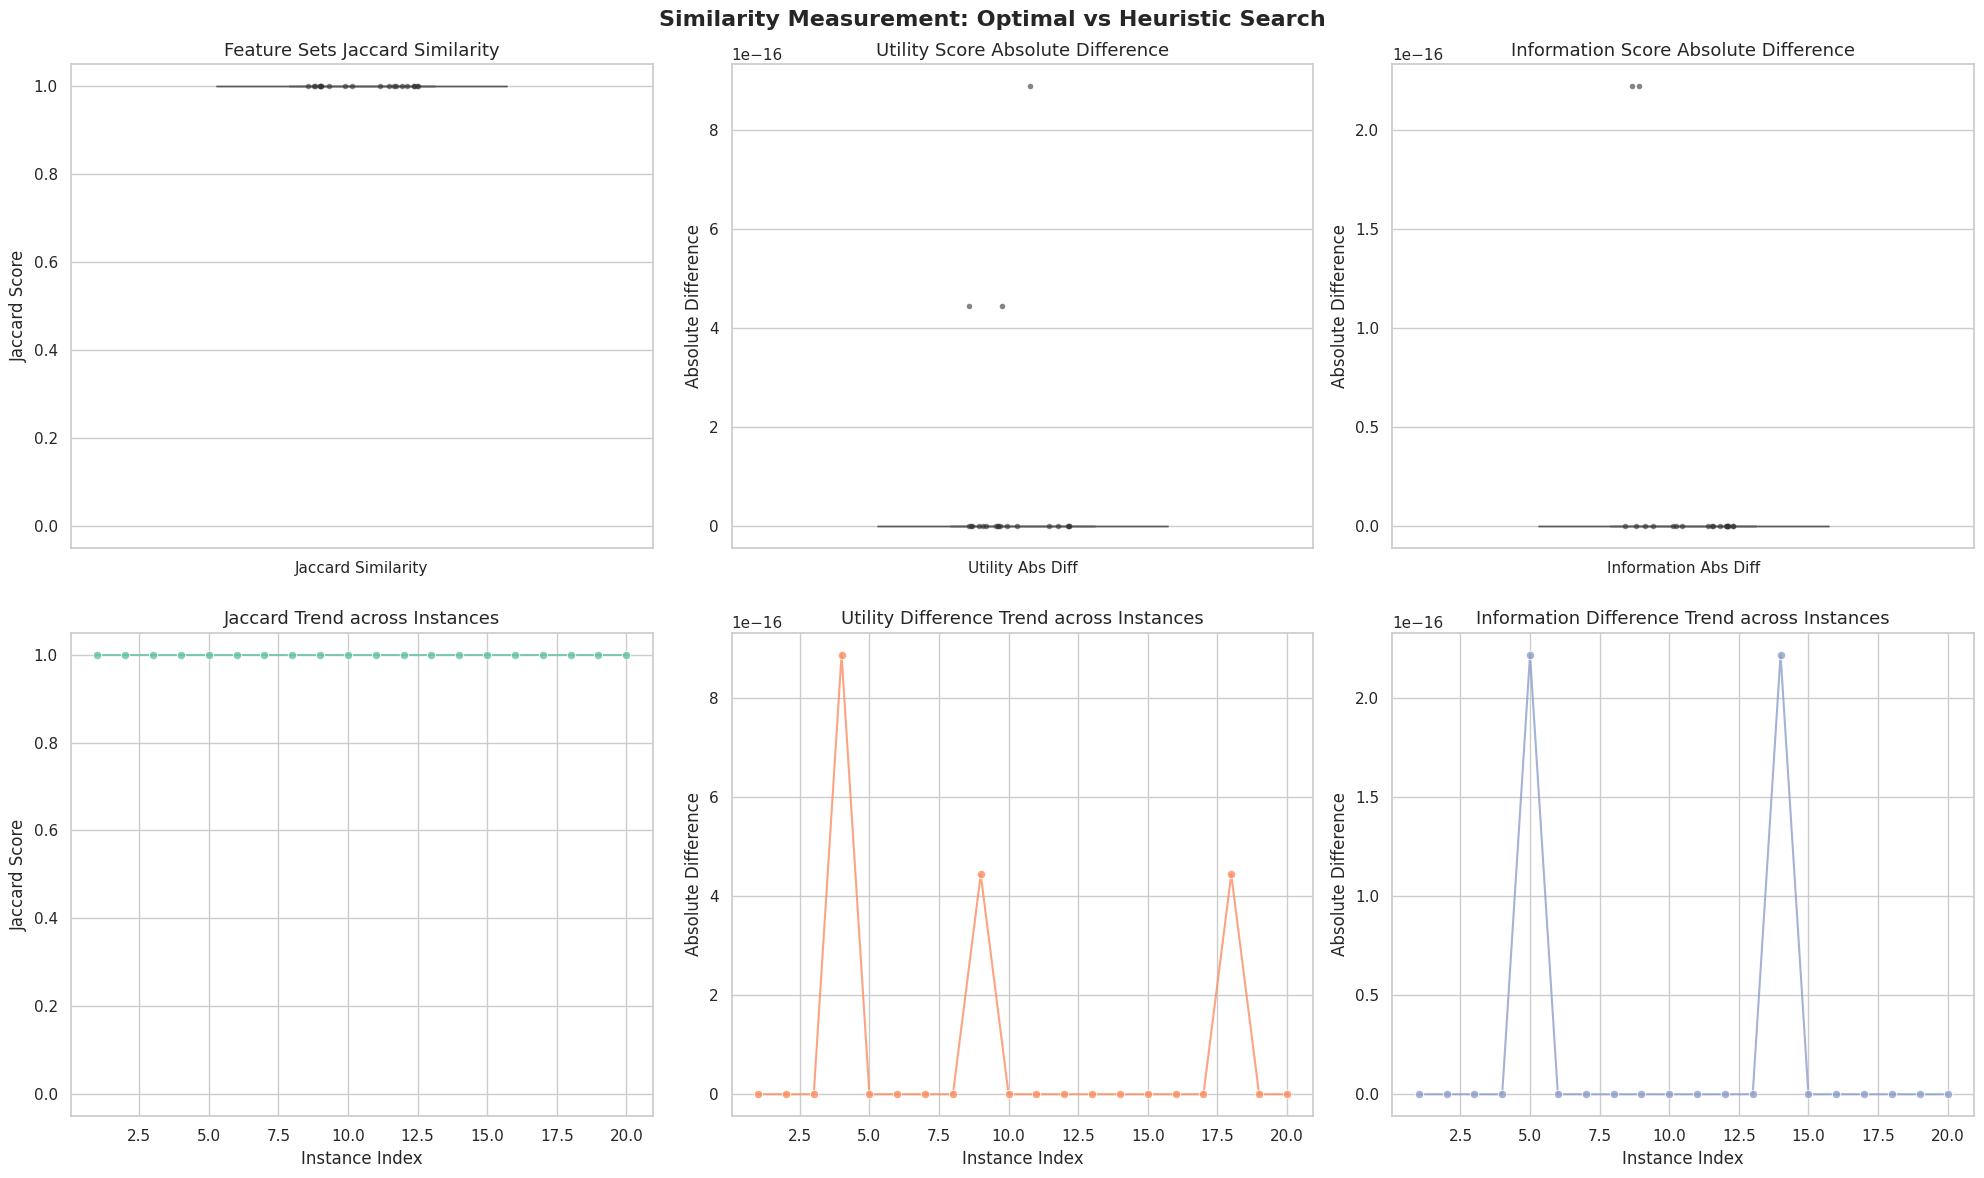

{'jaccard_similarity': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'utility_difference': [np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(8.881784197001252e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(0.0)],
 'information_difference': [np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(2.220446049250313e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(2.220446049250313e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0

In [14]:
patient_recommender = UtilityAlignedExplainerUser(
    model = heart_model,
    features=heart_features,
    actions=patient_actions,
    X_train=X_train_heart,
    X_test=X_test_heart,
    causal_model=patient_causal,
    utility_matrix=patient_utility_matrix,
    n_samples=20
)

patient_recommender.similarity_measurement(display = True)

### Doctor-based

In [15]:
doctor_actions = ['prescribe_statins', 'prescribe_beta_blockers', 'order_angiography', 'refer_to_surgery']

doctor_utility_matrix = np.array([
    [-2,  5,  5,   3,   1],  # prescribe_statins
    [-3,  3,  6,   5,   2],  # prescribe_beta_blockers
    [-5,  0,  6,   8,  10],  # order_angiography
    [-10,-5, -2,  10,  15]   # refer_to_surgery
])

doctor_causal = CausalModel(features=heart_features, actions=doctor_actions)
add_pathophysiology_edges(doctor_causal)

doctor_causal.add_causal_edge('chol', 'prescribe_statins')
doctor_causal.add_causal_edge('age', 'prescribe_statins')

doctor_causal.add_causal_edge('trestbps', 'prescribe_beta_blockers')
doctor_causal.add_causal_edge('thalach', 'prescribe_beta_blockers')
doctor_causal.add_causal_edge('oldpeak', 'prescribe_beta_blockers')

doctor_causal.add_causal_edge('cp', 'order_angiography')
doctor_causal.add_causal_edge('slope', 'order_angiography')
doctor_causal.add_causal_edge('thal', 'order_angiography')

doctor_causal.add_causal_edge('ca', 'refer_to_surgery')
doctor_causal.add_causal_edge('thal', 'refer_to_surgery')
doctor_causal.add_causal_edge('oldpeak', 'refer_to_surgery')

/home/alexis/UtilityAlignedExplainer/decision_maker.py:1122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_jaccard, x="Metric", y="Score", ax=axes[0, 0], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_utility, x="Metric", y="Score", ax=axes[0, 1], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:1135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_info, x="Metric", 

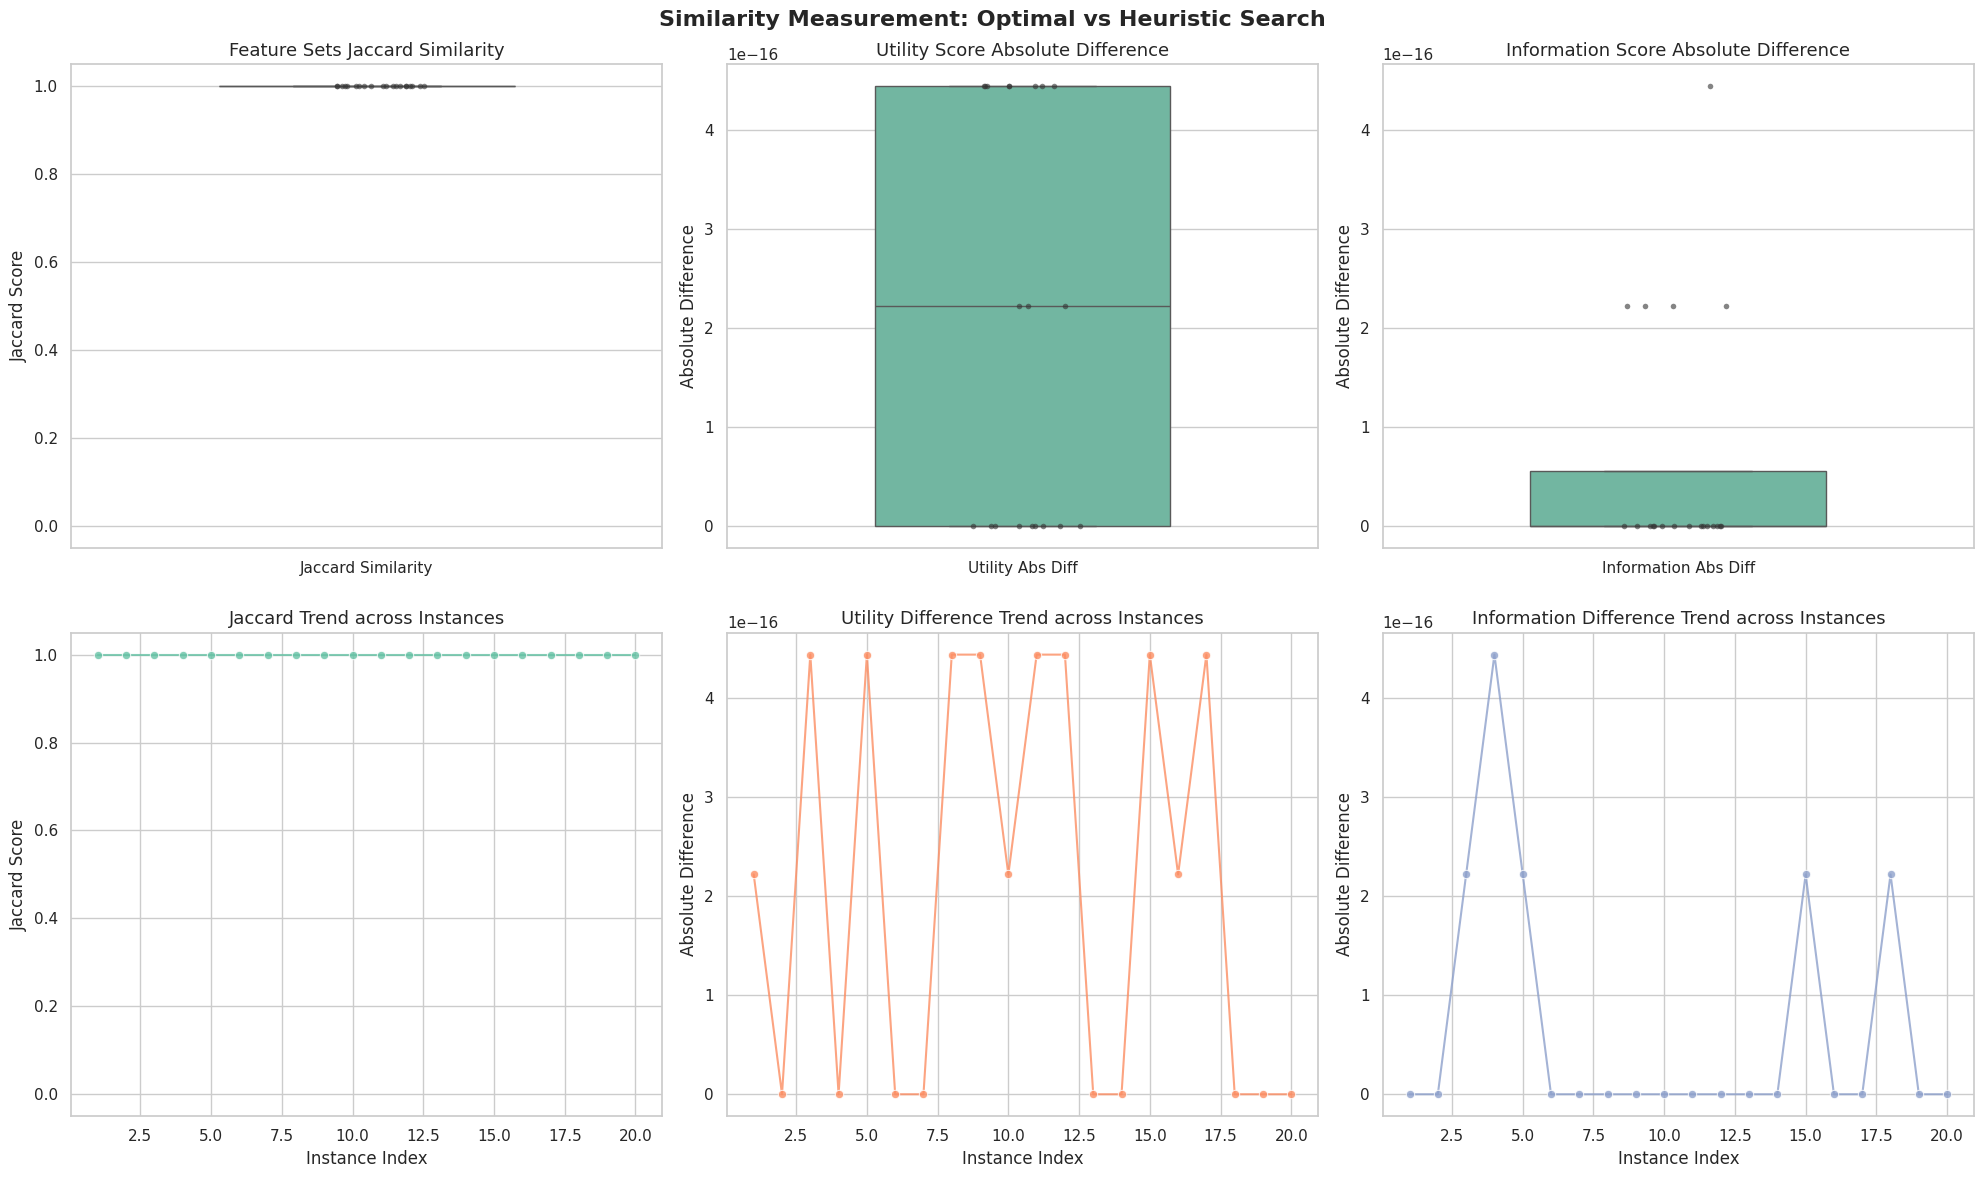

{'jaccard_similarity': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'utility_difference': [np.float64(2.220446049250313e-16),
  np.float64(0.0),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(4.440892098500626e-16),
  np.float64(4.440892098500626e-16),
  np.float64(2.220446049250313e-16),
  np.float64(4.440892098500626e-16),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(4.440892098500626e-16),
  np.float64(2.220446049250313e-16),
  np.float64(4.440892098500626e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0)],
 'information_difference': [np.float64(0.0),
  np.float64(0.0),
  np.float64(2.220446049250313e-16),
  np.float64(4.440892098500626e-16),
  np.float64(2.220446049250313e-16),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0),
  np

In [16]:
doctor_recommender = UtilityAlignedExplainerUser(
    model = heart_model,
    features=heart_features,
    actions=doctor_actions,
    X_train=X_train_heart,
    X_test=X_test_heart,
    causal_model=doctor_causal,
    utility_matrix=doctor_utility_matrix,
    n_samples=20
)

doctor_recommender.similarity_measurement(display = True)